# Spike and Recovery for Mouse and Human samples

In [1]:
import sys
sys.path.insert(0, '..')

import random
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import scipy

from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

from matplotlib.ticker import ScalarFormatter
import warnings
import copy
from utils.utils import *

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
np.random.seed(1)
random.seed(42)

pd.options.mode.chained_assignment = None

def clean_cals_vals(cals, vals, conc_epsilon=1e-5):
  melted_cals = {}
  calambnames = ['amb1','amb2', 'amb3','amb4']
  calmeanpnames = ['meanp1','meanp2', 'meanp3','meanp4']
  calmeannames = ['mean_all1','mean_all2', 'mean_all3','mean_all4']
 
  for k, df in cals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()

    #df_avg['amb'] = np.nan
  
    df_avg['amb'] = stats.gmean(df[calambnames], axis=1, nan_policy='omit')
    df_avg['meanp'] = stats.gmean(df[calmeanpnames],  axis=1,nan_policy='omit')
    df_avg['mean_all'] = stats.gmean(df[calmeannames],  axis=1,nan_policy='omit')

    df_final = df_avg[['conc', 'amb', 'meanp', 'mean_all']].copy()
    melted_cals[k] = df_final
    melted_cals[k]['amb_deviation']=np.std(df[calambnames], axis=1)
    melted_cals[k]['meanp_deviation']=np.std(df[calmeanpnames], axis=1)
    melted_cals[k]['mean_all_deviation']=np.std(df[calmeannames], axis=1)

  melted_vals = {}
  for k, df in vals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()
    
    df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[['amb1','amb2']], axis=1, nan_policy='omit')

    df_avg['meanp'] = np.nan
    df_avg['meanp'] = stats.gmean(df[['meanp1','meanp2']],  axis=1,nan_policy='omit')

    df_avg['mean_all'] = np.nan
    df_avg['mean_all'] = stats.gmean(df[['mean_all1','mean_all2']],  axis=1,nan_policy='omit')

  

    df_final = df_avg[['amb', 'meanp', 'mean_all']].copy()
    melted_vals[k] = df_final

  cals = melted_cals
  vals = melted_vals

  for k, df in cals.items():
    cals[k]['conc'] = df['conc'].astype(float)+conc_epsilon
    cals[k]['amb'] = df['amb'].astype(float)
    cals[k]['meanp'] = df['meanp'].astype(float)

  for k, df in vals.items():
    vals[k]['amb'] = df['amb'].astype(float)
    vals[k]['meanp'] = df['meanp'].astype(float)
  return cals, vals

In [2]:

data_path='../measurement_data/'
figures='../paper_and_outputs/figures/'

cytokine_dict = {
    'IL6': 'IL-6',
    'IL10': 'IL-10',
    'IL18': 'IL-18',
    'TNFa': 'TNF-\u03b1',
    'IL1b/IL23': 'IL-1\u03b2/IL-23',
    'IL22': 'IL-22',
    'IL17': 'IL-17'}

cytokine_dict_human = {
    'IL6': 'IL-6',
    'IL10': 'IL-10',
    'IL18': 'IL-18',
    'TNFa': 'TNF-\u03b1',
    'IL1b/IL23': 'IL-23',
    'IL22': 'IL-22',
    'IL17': 'IL-17'}

cytokine_dict_mouse = {
    'IL6': 'IL-6',
    'IL10': 'IL-10',
    'IL18': 'IL-18',
    'TNFa': 'TNF-\u03b1',
    'IL1b/IL23': 'IL-1\u03b2',
    'IL22': 'IL-22',
    'IL17': 'IL-17'}


mouse_order = ['TNFa','IL6', 'IL10',  'IL17','IL18', 'IL22', 'IL1b/IL23']
human_order = ['TNFa','IL6', 'IL10',  'IL17','IL18', 'IL22', 'IL1b/IL23']



In [3]:
# locate the mouse spike and recover data
sheet1 = pd.read_excel(data_path + 'S&R_mouse.xlsx',header=None)

il6 = sheet1.iloc[1:15,0:10]
il1b = sheet1.iloc[1:15,11:21]

il10 = sheet1.iloc[19:33,0:10]
il17 = sheet1.iloc[19:33,11:21]

tnfa = sheet1.iloc[38:52,0:10]
il22 = sheet1.iloc[38:52,11:21]

il18 = sheet1.iloc[55:69,0:10]

In [4]:
conc_epsilon= 0
lod_emb_epsilon=0.05
scale=  3.29 # this arises because LOD is 
#LOD=E_blank + 1.645*SD_blank + 1.645*SD_conc_lowest_standard      or equivalently
#LOD=E_blank + 3.29*(SD_blank+SD_lowest_standard)/2
lod_reduction = 1
amb_log_constant=0

In [5]:
cals = {}
data = {}

cals['IL22'] = il22.iloc[1:9,np.r_[0:5, 6:10]]
cals['IL1b/IL23'] = il1b.iloc[1:9,np.r_[0:5, 6:10]]
cals['IL6'] = il6.iloc[1:9,np.r_[0:5, 6:10]]

cals['IL10'] = il10.iloc[1:9,np.r_[0:5, 6:10]]
cals['IL17'] = il17.iloc[1:9,np.r_[0:5, 6:10]]
cals['IL18'] = il18.iloc[1:9,np.r_[0:5, 6:10]]

cals['TNFa'] = tnfa.iloc[1:9,np.r_[0:5, 6:10]]



for k,c in cals.items():
  cal_cols=['conc','amb1','amb2','amb3','amb4','meanp1','meanp2','meanp3','meanp4']
  c.columns = cal_cols
  c.reset_index(drop=True,inplace=True)
  for col in cal_cols:
    c[col] = c[col].astype(float)
  for col in cal_cols[1:]:
    c[col] = pd.to_numeric(c[col], errors='coerce')
  cals[k] = c


# We were not able to have four replicates for all the murine calibrators due to technical errors. We have excluded the following data points from the calibrators based on the following criteria:
# - Consecutive increases in AMB during dilution (indicating technical error)
# - 10 fold increase in signal during dilution at any one time (indicating technical error)
# - Blank is 3 fold higher than the lowest standard (indicating technical error)
for k,v in cals.items():
  if (k=='TNFa'): #(k=='IL6') or
    v['amb3'] = np.nan
    v['amb4'] = np.nan
  if (k=='IL17'): #(k=='IL6') or
    v['amb3'] = np.nan
  if (k=='IL6'):
    v['amb4'] = np.nan
  if (k=='IL6'):
    v['amb4'] = np.nan
  if (k=='IL1b/IL23'):
    v['amb2'] = np.nan 
  cals[k] = v


for k,c in cals.items():
  c['lambda1'] = amb_to_on(c['amb1'])
  c['lambda2'] = amb_to_on(c['amb2'])
  c['lambda3'] = amb_to_on(c['amb3'])
  c['lambda4'] = amb_to_on(c['amb4'])
  c['mean_all1'] =c['lambda1']*c['meanp1']
  c['mean_all2'] =c['lambda2']*c['meanp2']
  c['mean_all3'] =c['lambda3']*c['meanp3']
  c['mean_all4'] =c['lambda4']*c['meanp4']
  cals[k] = c

data['IL22'] = il22.iloc[11:,[0,1,2,6,7]]
data['IL1b/IL23'] = il1b.iloc[11:,[0,1,2,6,7]]
data['IL6'] = il6.iloc[11:,[0,1,2,6,7]]

data['IL10'] = il10.iloc[11:,[0,1,2,6,7]]
data['IL17'] = il17.iloc[11:,[0,1,2,6,7]]
data['IL18'] = il18.iloc[11:,[0,1,2,6,7]]

data['TNFa'] = tnfa.iloc[11:,[0,1,2,6,7]]

#data['tnfa gate'] = tnfa_gate.iloc[10:,[1,11,12,2,3]]

for k,v in data.items():
  v.columns = ['sample','amb1','amb2','meanp1','meanp2']
  v.reset_index(drop=True,inplace=True)
  v['sample'] = v['sample'].astype(str)
  v['amb1'] = v['amb1'].replace("not enough sample", np.nan)
  v['amb2'] = v['amb2'].replace("not enough sample", np.nan)
  v['amb1'] = v['amb1'].astype(float)
  v['amb2'] = v['amb2'].astype(float)
  v['meanp1'] = v['meanp1'].astype(float)
  v['meanp2'] = v['meanp2'].astype(float)
  data[k] = v

for k,v in data.items():
  v['amb1'] = pd.to_numeric(v['amb1'], errors='coerce')
  v['amb2'] = pd.to_numeric(v['amb2'], errors='coerce')
  v['meanp1'] = pd.to_numeric(v['meanp1'], errors='coerce')
  v['meanp2'] = pd.to_numeric(v['meanp2'], errors='coerce')
  data[k] = v

for k,v in data.items():
  v['lambda1'] = amb_to_on(v['amb1'])
  v['lambda2'] = amb_to_on(v['amb2'])
  v['mean_all1'] =v['lambda1']*v['meanp1']
  v['mean_all2'] =v['lambda2']*v['meanp2']
  data[k] = v

In [6]:
cals,vals=clean_cals_vals(cals, data, conc_epsilon=conc_epsilon)
cals = {k: cals[k] for k in mouse_order}
vals = {k: vals[k] for k in mouse_order}

/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


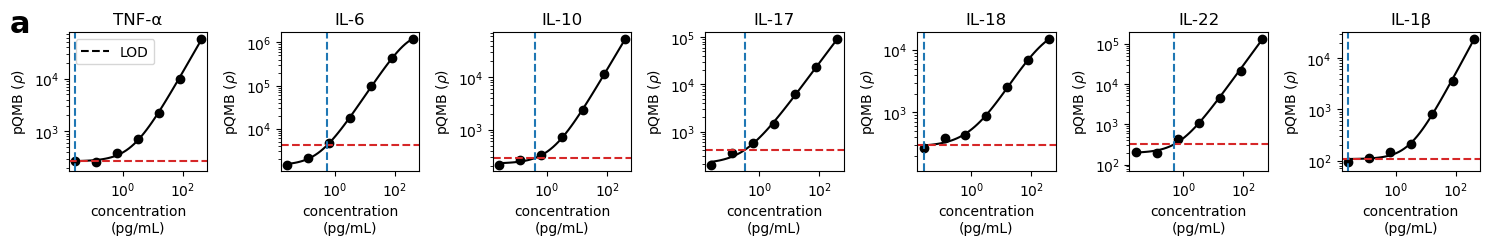

In [7]:
params = {}
conclimits = {}
measurelimits = {}
llod = {}
llod_conc = {}
llod_conc_ll = {}
ulod = {}
ulod_conc = {}
ulod_conc_ll = {}
xf={}
yf={}
fig, axes = plt.subplots(1, 7, figsize=(15, 3))
axes = axes.flatten()
axes2 = axes.copy()

ambval='mean_all'
ambdev='mean_all_deviation'

for i, (k, df) in enumerate(cals.items()):
  xf[k, ambval], yf[k, ambval], params[k, ambval] = cal_curve_fit(df, x_var='conc', y_var=ambval)

  # Get lowest non-zero concentration
  min_nonzero_conc = min(df[df['conc'] > 0]['conc'])
  max_nonzero_conc = max(df['conc'])
  amb_at_min_conc = df[df['conc'] == min_nonzero_conc][ambval]

  conclimits[k] = (min_nonzero_conc, max(df['conc']))
  measurelimits[k,ambval] = (min(amb_at_min_conc), max(df[ambval]))

  axes[i].plot(xf[k,ambval],yf[k,ambval], color='k')

  lasymp= df[ambval][7]
  lstandard_deviation=(df[ambdev][7]+df[ambdev][6])/2

  llod_std = lasymp+scale*lstandard_deviation

  llod_lowest_conc=linear_5pl(min_nonzero_conc, *params[k, ambval])
  llod[k] = max(llod_std,llod_lowest_conc)
  

  llod_conc[k]=invlog5pl(llod[k], (params[k, ambval],conclimits[k],measurelimits[k, ambval]))


  axes[i].axhline(y=llod[k], color='tab:red', linestyle='--')
  axes[i].axvline(x=llod_conc[k], color='tab:blue', linestyle='--')

  conclimits[k] = (llod_conc[k], conclimits[k][1])
  measurelimits[k, ambval] = (llod[k], measurelimits[k, ambval][1])
  
  axes[i].scatter(df['conc'],df[ambval], color='k')

  axes[i].set_yscale('log')
  #axes2[i].set_yscale('log')
  axes[i].set_xscale('log')
  axes[i].set_title(cytokine_dict_mouse[k])
  axes[i].set_xlabel('concentration\n(pg/mL)')
  axes[i].set_ylabel(r'pQMB ($\rho$)')
  axes[i].set_box_aspect(1)
# add legend for the dashed lines in the empty subplot
custom_lines = [Line2D([0], [0], color='k', linestyle='--')]
axes[0].legend(custom_lines, ['LOD'], loc='upper left', fontsize=10)

fig.text(0.01, 0.84, 'a', fontsize=22, fontweight='bold', va='top', ha='left')

plt.tight_layout()

plt.savefig(figures+'mouse_SR_curves.pdf', bbox_inches='tight')

In [8]:
for k,v in vals.items():
  v['calculated_conc_amb'] = v[ambval].apply(invlog5pl_after_lod, superparams=(params[k,ambval],conclimits[k],measurelimits[k, ambval]))
  v['calculated_conc'] = v['calculated_conc_amb']# spike is after dilution so no need for dilution correction its all relative to unspiked measurement
  
  v['lod'] = llod_conc[k]
  vals[k] = v

for k,v in vals.items():
  _=v['calculated_conc'] 
  #print([_[0]-_[0], _[1]-_[0], _[2]-_[0]])
  v['corrected']=[ _[0]-_[0],_[1]-_[0], _[2]-_[0]]
  v['additive'] =  [_[0]+_[0],_[1]+_[0], _[2]+_[0]]
  v['true'] =[0, 80, 3.2]
  v['base'] = [_[0], _[0], _[0]]

  v['true_additive'] =[_[0]+v['true'][0],_[0]+v['true'][1],_[0]+v['true'][2]]
  v['error'] = (v['corrected'] - v['true'])
  v['relative_error'] = v['error']/v['true']
  v['abs relative_error'] = np.abs(v['relative_error'])
  v['percent_recovery_sub'] = (v['corrected']/v['true'])*100
  v['percent_recovery_add'] = (v['calculated_conc']/v['true_additive'])*100
  v['label'] = ['control', 'high spike', 'low spike']
  v['rep'] = ['replicate 1', 'replicate 1', 'replicate 1' ]
  v['mammal'] = ['mouse', 'mouse', 'mouse' ]
  vals[k] = v

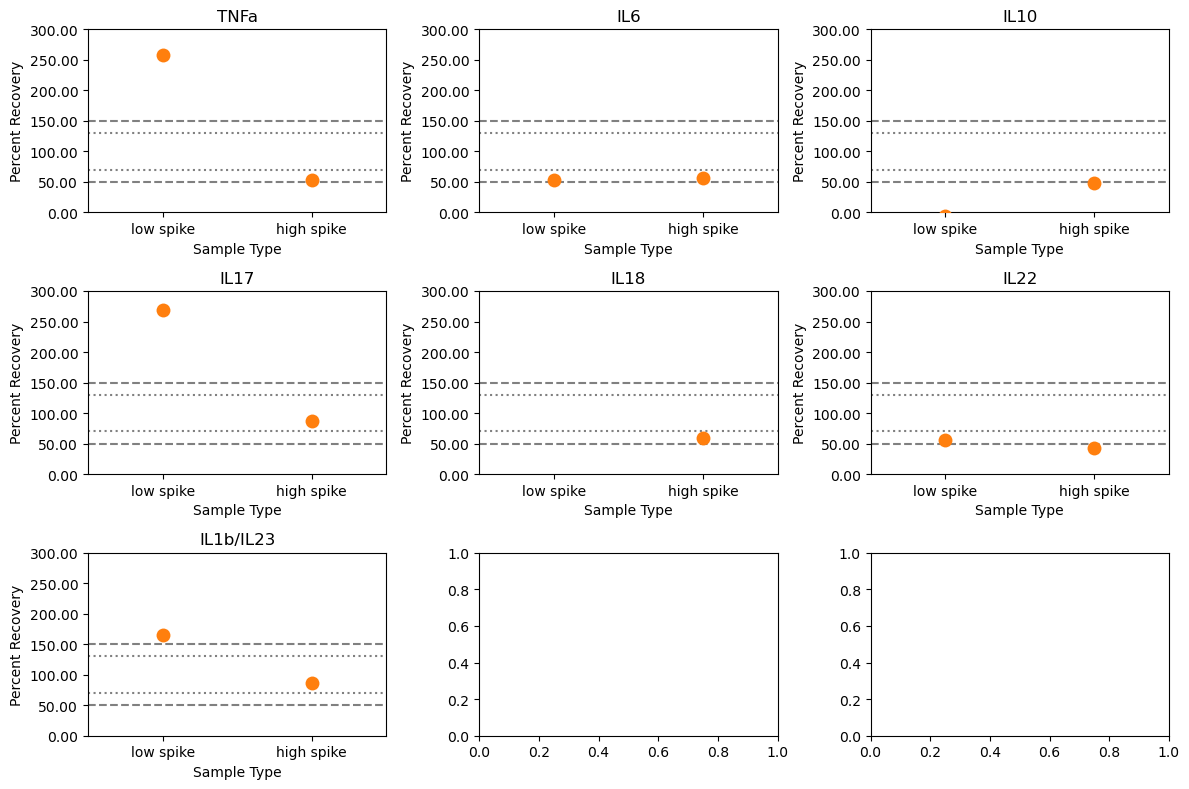

In [9]:

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()
for i, (k, df) in enumerate(vals.items()):
  df_clean = df[df['true']!=0]
  
  sns.swarmplot(x='label', y='percent_recovery_sub', data=df_clean, ax=axes[i], color='tab:orange', s=10, marker='o', order =['low spike', 'high spike'])

  axes[i].set_title(k)
  axes[i].set_ylabel('Percent Recovery')
  axes[i].set_xlabel('Sample Type')
  axes[i].axhline(y=130, color='gray', linestyle=':')
  axes[i].axhline(y=70, color='gray', linestyle=':')
  axes[i].axhline(y=150, color='gray', linestyle='--')
  axes[i].axhline(y=50, color='gray', linestyle='--')

  #axes[i].set_yscale('log')
  axes[i].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
  axes[i].set_ylim(0, 300)  # Set y-axis limits for better visualization
 # Remove the empty subplot

plt.tight_layout()
plt.show()

#some background measurements were above low spike amount, and so those recoveries are not interpretable and are removed from the final plot at the end of the notebook 


In [10]:
# flatten the cytokine abundandces into a single dataframe for analysis
allvals = []
for k,v in vals.items():
  df = v.copy()
  df_clean = df[df['true']!=0]
  df_clean['cytokine'] = k
  allvals.append(df_clean)
allvals_df = pd.concat(allvals, ignore_index=True)

In [11]:
mouse_cals = cals.copy()
mouse_vals = vals.copy()
mouse_allvals_df= allvals_df.copy()

In [12]:
sheet1 = pd.read_excel(data_path+'S&R_human.xlsx',header=None)

sheet1
il22 = sheet1.iloc[1:18,1:7]
il23 = sheet1.iloc[1:18,8:14]
il6 = sheet1.iloc[1:18,15:21]

il10 = sheet1.iloc[20:37,1:7]
il17 = sheet1.iloc[20:37,8:14]
il18 = sheet1.iloc[20:37,15:21]

tnfa = sheet1.iloc[39:56,1:7]

In [13]:
def clean_cals_vals(cals, vals, conc_epsilon=1e-5):
  melted_cals = {}
  calambnames = ['amb1','amb2']
  callogambnames = ['log_amb1','log_amb2']
  calmeanpnames = ['meanp1','meanp2']
  callogmeanpnames = ['log_meanp1','log_meanp2']
  calmeannames = ['mean_all1','mean_all2']
  callogmeannames = ['log_mean_all1','log_mean_all2']
  
  for k, df in cals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()

    #df_avg['amb'] = np.nan
  
    df_avg['amb'] = stats.gmean(df[calambnames], axis=1, nan_policy='omit')
    df_avg['lambda'] = stats.gmean(df[['lambda1','lambda2']], axis=1, nan_policy='omit')
    df_avg['log_amb'] = stats.gmean(df[callogambnames], axis=1, nan_policy='omit')
    df_avg['meanp'] = stats.gmean(df[calmeanpnames],  axis=1,nan_policy='omit')
    df_avg['log_meanp'] = stats.gmean(df[callogmeanpnames],  axis=1,nan_policy='omit') 
    df_avg['mean_all'] = stats.gmean(df[calmeannames],  axis=1,nan_policy='omit')
    df_avg['log_mean_all'] = stats.gmean(df[callogmeannames],  axis=1,nan_policy='omit')  

    df_final = df_avg[['conc', 'amb', 'lambda', 'meanp', 'log_amb', 'log_meanp', 'mean_all', 'log_mean_all']].copy()
    melted_cals[k] = df_final
    melted_cals[k]['amb_deviation']=np.std(df[calambnames], axis=1)
    melted_cals[k]['meanp_deviation']=np.std(df[calmeanpnames], axis=1)
    melted_cals[k]['log_amb_deviation']=np.std(df[callogambnames], axis=1)
    melted_cals[k]['log_meanp_deviation']=np.std(df[callogmeanpnames], axis=1)
    melted_cals[k]['mean_all_deviation']=np.std(df[calmeannames], axis=1)
    melted_cals[k]['log_mean_all_deviation']=np.std(df[callogmeannames], axis=1)

  melted_vals = {}
  for k, df in vals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()
    
    df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[['amb1','amb2']], axis=1, nan_policy='omit')

    df_avg['lambda'] = np.nan
    df_avg['lambda'] = stats.gmean(df[['lambda1','lambda2']], axis=1, nan_policy='omit')

    df_avg['log_amb'] = np.nan
    df_avg['log_amb'] = stats.gmean(df[['log_amb1','log_amb2']], axis=1, nan_policy='omit')

    df_avg['meanp'] = np.nan
    df_avg['meanp'] = stats.gmean(df[['meanp1','meanp2']],  axis=1,nan_policy='omit')
    df_avg['log_meanp'] = stats.gmean(df[['log_meanp1','log_meanp2']],  axis=1,nan_policy='omit')

    df_avg['mean_all'] = np.nan
    df_avg['mean_all'] = stats.gmean(df[['mean_all1','mean_all2']],  axis=1,nan_policy='omit')

    df_avg['log_mean_all'] = np.nan
    df_avg['log_mean_all'] = stats.gmean(df[['log_mean_all1','log_mean_all2']],  axis=1,nan_policy='omit') 

    df_final = df_avg[['amb', 'lambda', 'meanp', 'log_amb', 'log_meanp', 'mean_all', 'log_mean_all']].copy()
    melted_vals[k] = df_final

  cals = melted_cals
  vals = melted_vals

  for k, df in cals.items():
    cals[k]['conc'] = df['conc'].astype(float)+conc_epsilon
    cals[k]['amb'] = df['amb'].astype(float)
    cals[k]['meanp'] = df['meanp'].astype(float)
    cals[k]['log_amb'] = df['log_amb'].astype(float)
    cals[k]['log_meanp'] = df['log_meanp'].astype(float)

  for k, df in vals.items():
    vals[k]['amb'] = df['amb'].astype(float)
    vals[k]['log_amb'] = df['log_amb'].astype(float)
    vals[k]['meanp'] = df['meanp'].astype(float)
    vals[k]['log_meanp'] = df['log_meanp'].astype(float)
  return cals, vals

In [14]:
cals = {}
data = {}

cals['IL22'] = il22.iloc[0:8,0:5]
cals['IL1b/IL23'] = il23.iloc[0:8,0:5]
cals['IL6'] = il6.iloc[0:8,0:5]

cals['IL10'] = il10.iloc[0:8,0:5]
cals['IL17'] = il17.iloc[0:8,0:5]
cals['IL18'] = il18.iloc[0:8,0:5]

cals['TNFa'] = tnfa.iloc[0:8,0:5]

for k,c in cals.items():
  c.columns = ['conc','amb1','amb2','meanp1','meanp2']
  c.reset_index(drop=True,inplace=True)
  c['conc'] = c['conc'].astype(float)
  c['amb1'] = c['amb1'].astype(float)
  c['amb2'] = c['amb2'].astype(float)
  c['meanp1'] = c['meanp1'].astype(float)
  c['meanp2'] = c['meanp2'].astype(float)
  cals[k] = c

for k,c in cals.items():
  c['amb1'] = pd.to_numeric(c['amb1'], errors='coerce')
  c['amb2'] = pd.to_numeric(c['amb2'], errors='coerce')
  c['meanp1'] = pd.to_numeric(c['meanp1'], errors='coerce')
  c['meanp2'] = pd.to_numeric(c['meanp2'], errors='coerce')
  cals[k] = c

for k,c in cals.items():
  c['log_amb1'] = np.log(c['amb1'])+amb_log_constant
  c['log_amb2'] = np.log(c['amb2'])+amb_log_constant
  c['log_meanp1'] = np.log(c['meanp1'])
  c['log_meanp2'] = np.log(c['meanp2'])
  c['lambda1'] = amb_to_on(c['amb1'])
  c['lambda2'] = amb_to_on(c['amb2'])
  c['mean_all1'] =c['lambda1']*c['meanp1']
  c['mean_all2'] =c['lambda2']*c['meanp2']
  c['log_mean_all1'] = np.log(c['mean_all1'])
  c['log_mean_all2'] = np.log(c['mean_all2'])
  cals[k] = c

data['IL22'] = il22.iloc[11:,[0,1,2,3,4,5]]
data['IL1b/IL23'] = il23.iloc[11:,[0,1,2,3,4,5]]
data['IL6'] = il6.iloc[11:,[0,1,2,3,4,5]]

data['IL10'] = il10.iloc[11:,[0,1,2,3,4,5]]
data['IL17'] = il17.iloc[11:,[0,1,2,3,4,5]]
data['IL18'] = il18.iloc[11:,[0,1,2,3,4,5]]

data['TNFa'] = tnfa.iloc[11:,[0,1,2,3,4,5]]

for k,v in data.items():
  v.columns = ['sample','notes','amb1','amb2','meanp1','meanp2']
  v.reset_index(drop=True,inplace=True)
  v['sample'] = v['sample'].astype(str)
  v['amb1'] = v['amb1'].replace("not enough sample", np.nan)
  v['amb2'] = v['amb2'].replace("not enough sample", np.nan)
  v['amb1'] = v['amb1'].astype(float)
  v['amb2'] = v['amb2'].astype(float)
  v['meanp1'] = v['meanp1'].astype(float)
  v['meanp2'] = v['meanp2'].astype(float)
  data[k] = v

for k,v in data.items():
  v['amb1'] = pd.to_numeric(v['amb1'], errors='coerce')
  v['amb2'] = pd.to_numeric(v['amb2'], errors='coerce')
  v['meanp1'] = pd.to_numeric(v['meanp1'], errors='coerce')
  v['meanp2'] = pd.to_numeric(v['meanp2'], errors='coerce')
  data[k] = v

for k,v in data.items():
  v['log_amb1'] = np.log(v['amb1'])+amb_log_constant
  v['log_amb2'] = np.log(v['amb2'])+amb_log_constant
  v['log_meanp1'] = np.log(v['meanp1'])
  v['log_meanp2'] = np.log(v['meanp2'])
  v['lambda1'] = amb_to_on(v['amb1'])
  v['lambda2'] = amb_to_on(v['amb2'])
  v['mean_all1'] =v['lambda1']*v['meanp1']
  v['mean_all2'] =v['lambda2']*v['meanp2']
  v['log_mean_all1'] = np.log(v['mean_all1'])
  v['log_mean_all2'] = np.log(v['mean_all2'])
  data[k] = v

In [15]:
cals,vals=clean_cals_vals(cals, data, conc_epsilon=conc_epsilon)
cals = {k: cals[k] for k in human_order}
vals = {k: vals[k] for k in human_order}

/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/

In [16]:
vals['IL1b/IL23']

,amb,lambda,meanp,log_amb,log_meanp,mean_all,log_mean_all
0,0.023649,0.023371,12238.496640,NaN,9.412337,286.031171,5.656101
1,0.820415,0.559702,18764.455548,NaN,9.839695,10502.506127,9.259293
2,0.084245,0.080794,12593.909758,NaN,9.440934,1017.509291,6.925075
3,0.036361,0.035693,13008.797024,NaN,9.473367,464.319963,6.137368
4,0.953214,0.614498,20046.299160,NaN,9.905623,12318.414134,9.418679
5,0.093148,0.088941,12872.757746,NaN,9.462797,1144.921673,7.043040


/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


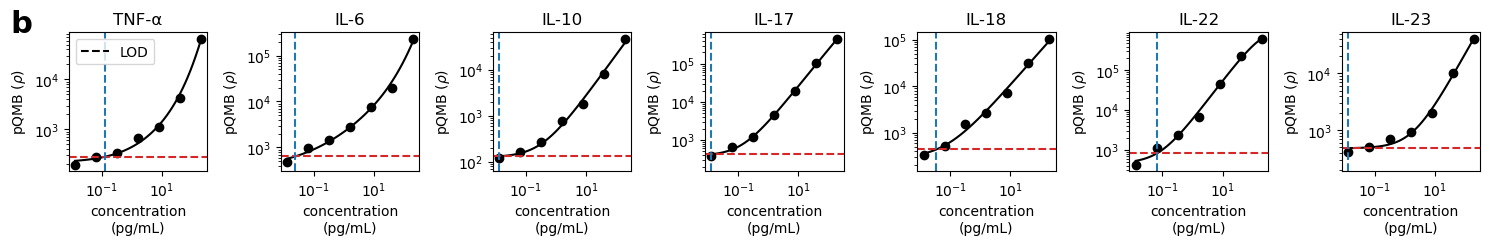

In [17]:
params = {}
conclimits = {}
measurelimits = {}
llod = {}
llod_conc = {}
llod_conc_ll = {}
ulod = {}
ulod_conc = {}
ulod_conc_ll = {}
xf={}
yf={}
fig, axes = plt.subplots(1, 7, figsize=(15, 3))
axes = axes.flatten()
axes2 = axes.copy()

ambval='mean_all'
ambdev='mean_all_deviation'

for i, (k, df) in enumerate(cals.items()):
  xf[k, ambval], yf[k, ambval], params[k, ambval] = cal_curve_fit(df, x_var='conc', y_var=ambval)

  # Get lowest non-zero concentration
  min_nonzero_conc = min(df[df['conc'] > 0]['conc'])
  max_nonzero_conc = max(df['conc'])
  amb_at_min_conc = df[df['conc'] == min_nonzero_conc][ambval]

  conclimits[k] = (min_nonzero_conc, max(df['conc']))
  measurelimits[k,ambval] = (min(amb_at_min_conc), max(df[ambval]))

  axes[i].plot(xf[k,ambval],yf[k,ambval], color='k')

  lasymp= df[ambval][7]
  lstandard_deviation=(df[ambdev][7]+df[ambdev][6])/2

  llod_std = lasymp+scale*lstandard_deviation

  llod_lowest_conc=linear_5pl(min_nonzero_conc, *params[k, ambval])
  llod[k] = max(llod_std,llod_lowest_conc)
  

  llod_conc[k]=invlog5pl(llod[k], (params[k, ambval],conclimits[k],measurelimits[k, ambval]))


  axes[i].axhline(y=llod[k], color='tab:red', linestyle='--')
  axes[i].axvline(x=llod_conc[k], color='tab:blue', linestyle='--')

  conclimits[k] = (llod_conc[k], conclimits[k][1])
  measurelimits[k, ambval] = (llod[k], measurelimits[k, ambval][1])
  
  axes[i].scatter(df['conc'],df[ambval], color='k')

  axes[i].set_yscale('log')
  #axes2[i].set_yscale('log')
  axes[i].set_xscale('log')
  axes[i].set_title(cytokine_dict_human[k])
  axes[i].set_xlabel('concentration\n(pg/mL)')
  axes[i].set_ylabel(r'pQMB ($\rho$)')
  axes[i].set_box_aspect(1)

custom_lines = [Line2D([0], [0], color='k', linestyle='--')]
axes[0].legend(custom_lines, ['LOD'], loc='upper left', fontsize=10)

# add letter d in upper left corner of the figure outside of the axes
fig.text(0.01, 0.84, 'b', fontsize=22, fontweight='bold', va='top', ha='left')

plt.tight_layout()

plt.savefig(figures+'human_SR_curves.pdf', bbox_inches='tight')

In [18]:
for k,v in vals.items():
  v['calculated_conc_amb'] = v[ambval].apply(invlog5pl_after_lod, superparams=(params[k,ambval],conclimits[k],measurelimits[k, ambval]))
  print(k)
  print(params[k,ambval])
  print(conclimits[k])
  print(measurelimits[k, ambval])

  #v['calculated_conc_mean'] = v[meanval].apply(invlog5pl_after_lod, superparams=(params[k,meanval],conclimits[k],measurelimits[k, meanval]))
  # chose calculated_conc from amb if amb is below 0.1
  v['calculated_conc'] = v['calculated_conc_amb']#np.where(v[ambval]<1, v['calculated_conc_amb'], v['calculated_conc_mean'])
  v['lod']=llod_conc[k]
  vals[k] = v

for k,v in vals.items():
  _=v['calculated_conc']
  print([_[0]-_[0], _[1]-_[0], _[2]-_[0],_[3]-_[3], _[4]-_[3],_[5]-_[3]])
  v['corrected']=[_[0]-_[0], _[1]-_[0], _[2]-_[0],_[3]-_[3], _[4]-_[3],_[5]-_[3]]
  v['true'] =[0, 40, 1.6, 0, 40, 1.6 ]
  v['base'] = [_[0], _[0], _[0], _[3], _[3], _[3]]
  v['true_additive'] =[_[0]+v['true'][0],_[0]+v['true'][1],_[0]+v['true'][2],_[3]+v['true'][3],_[3]+v['true'][4],_[3]+v['true'][5]]
  v['error'] = (v['corrected'] - v['true'])
  v['relative_error'] = v['error']/v['true']
  v['abs relative_error'] = np.abs(v['relative_error'])
  v['percent_recovery_sub'] = (v['corrected']/v['true'])*100
  v['percent_recovery_add'] = (v['calculated_conc']/v['true_additive'])*100
  v['label'] = ['control', 'high spike', 'low spike', 'control', 'high spike', 'low spike']
  v['rep'] = ['replicate 1', 'replicate 1', 'replicate 1', 'replicate 2', 'replicate 2', 'replicate 2']
  v['mammal'] = ['human', 'human', 'human', 'human', 'human', 'human']
  vals[k] = v

TNFa
[ 214.41469845    0.54090186  331.56640167 -316.78986312   -8.40158013]
(array(0.13218763), 200.0)
(np.float64(282.6933760196036), 65688.81117313314)
IL6
[ 3.64439378e+02  4.59377192e-01  3.95468265e+02 -2.58008861e+03
 -7.73454541e+00]
(array(0.02367282), 200.0)
(np.float64(636.3349438553875), 231704.56379132892)
IL10
[1.25798271e+02 8.97316117e-01 1.99858757e+04 4.62939729e+07
 5.27707427e-02]
(array(0.0128), 200.0)
(np.float64(132.5649659484625), 47093.99287524977)
IL17
[3.84345315e+02 9.77485301e-01 2.53658305e+03 6.79260150e+07
 8.40377376e-02]
(array(0.0128), 200.0)
(np.float64(422.2531164139509), 459985.7806497941)
IL18
[2.78851821e+02 7.38497691e-01 1.77225907e+04 6.87956380e+07
 3.86312392e-02]
(array(0.0344031), 200.0)
(np.float64(439.63375398369163), 105761.50200547003)
IL22
[4.54942450e+02 1.00096032e+00 7.29860140e+03 8.92689160e+05
 4.53342551e+01]
(array(0.06384859), 200.0)
(np.float64(804.7849749952342), 606605.3755153128)
IL1b/IL23
[4.77671084e+02 9.61785418e-01 5

/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encounter

In [19]:
vals['IL1b/IL23']

,amb,lambda,meanp,log_amb,log_meanp,mean_all,log_mean_all,calculated_conc_amb,calculated_conc,lod,...,base,true_additive,error,relative_error,abs relative_error,percent_recovery_sub,percent_recovery_add,label,rep,mammal
0,0.023649,0.023371,12238.496640,NaN,9.412337,286.031171,5.656101,0.012800,0.012800,0.0128,...,0.0128,0.0128,0.000000,NaN,NaN,NaN,100.000000,control,replicate 1,human
1,0.820415,0.559702,18764.455548,NaN,9.839695,10502.506127,9.259293,46.009434,46.009434,0.0128,...,0.0128,40.0128,5.996634,0.149916,0.149916,114.991585,114.986790,high spike,replicate 1,human
2,0.084245,0.080794,12593.909758,NaN,9.440934,1017.509291,6.925075,2.193243,2.193243,0.0128,...,0.0128,1.6128,0.580443,0.362777,0.362777,136.277715,135.989796,low spike,replicate 1,human
3,0.036361,0.035693,13008.797024,NaN,9.473367,464.319963,6.137368,0.012800,0.012800,0.0128,...,0.0128,0.0128,0.000000,NaN,NaN,NaN,100.000000,control,replicate 2,human
4,0.953214,0.614498,20046.299160,NaN,9.905623,12318.414134,9.418679,54.765490,54.765490,0.0128,...,0.0128,40.0128,14.752690,0.368817,0.368817,136.881724,136.869926,high spike,replicate 2,human
5,0.093148,0.088941,12872.757746,NaN,9.462797,1144.921673,7.043040,2.734026,2.734026,0.0128,...,0.0128,1.6128,1.121226,0.700766,0.700766,170.076611,169.520448,low spike,replicate 2,human


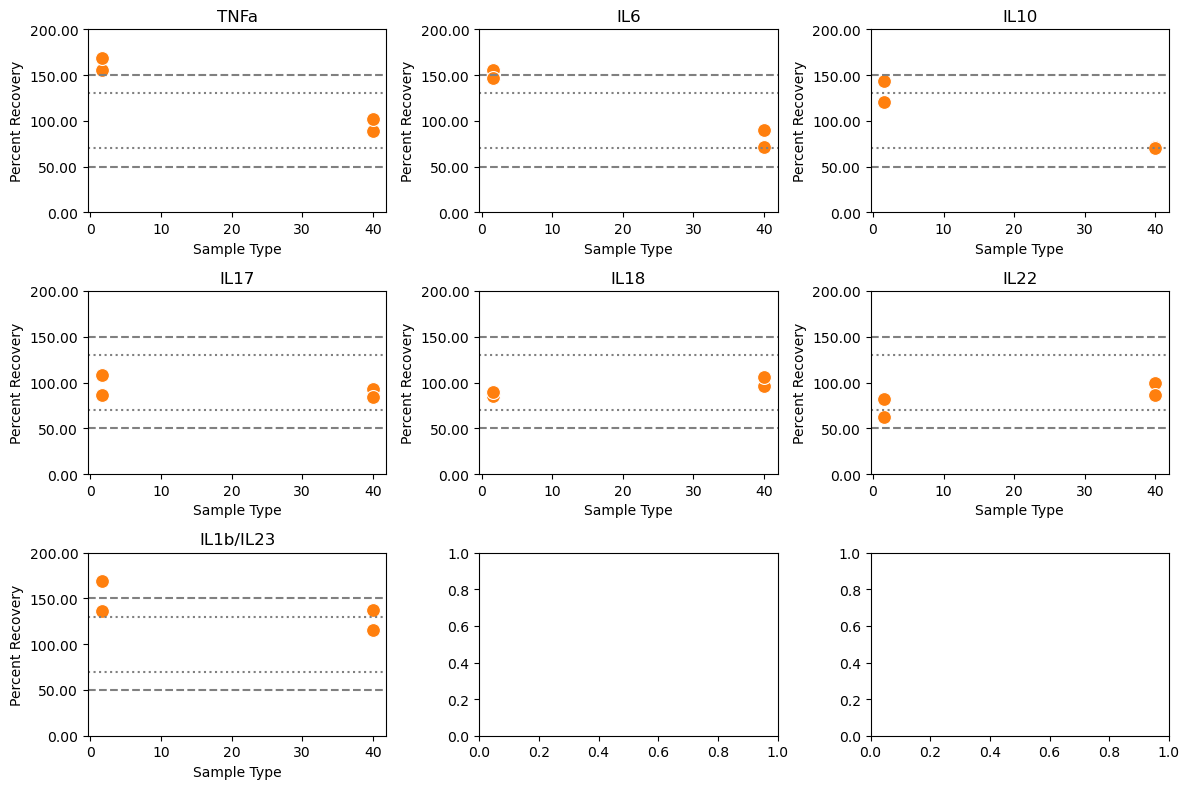

In [20]:

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()
for i, (k, df) in enumerate(vals.items()):
  df_clean = df[df['true']!=0]
  sns.scatterplot(x='true', y='percent_recovery_add', data=df_clean, ax=axes[i], color='tab:orange', s=100, marker='o')

  axes[i].set_title(k)
  axes[i].set_ylabel('Percent Recovery')
  axes[i].set_xlabel('Sample Type')
  axes[i].axhline(y=130, color='gray', linestyle=':')
  axes[i].axhline(y=70, color='gray', linestyle=':')
  axes[i].axhline(y=150, color='gray', linestyle='--')
  axes[i].axhline(y=50, color='gray', linestyle='--')

  #axes[i].set_yscale('log')
  axes[i].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
  axes[i].set_ylim(0, 200)  # Set y-axis limits for better visualization
 # Remove the empty subplot

plt.tight_layout()
plt.show()

In [21]:
# flatten the cytokine abundandces into a single dataframe for analysis
allvals = []
for k,v in vals.items():
  df = v.copy()
  df_clean = df[df['true']!=0]
  df_clean['cytokine'] = k
  allvals.append(df_clean)    
  
allvals_df = pd.concat(allvals, ignore_index=True) 

In [22]:
# for the dataframe mouse_allvals_df replace the 'low spike' with 'low spike mouse' and 'high spike' with 'high spike mouse' in the 'label' column
mouse_allvals_df['label'] = mouse_allvals_df['label'].replace({'low spike': 'low spike mouse', 'high spike': 'high spike mouse'})

# do the same for allvals_df to have 'low spike human' and 'high spike human'
allvals_df['label'] = allvals_df['label'].replace({'low spike': 'low spike human', 'high spike': 'high spike human'}) 


Text(0, 0.5, 'Percent Recovery (Additive Method)')

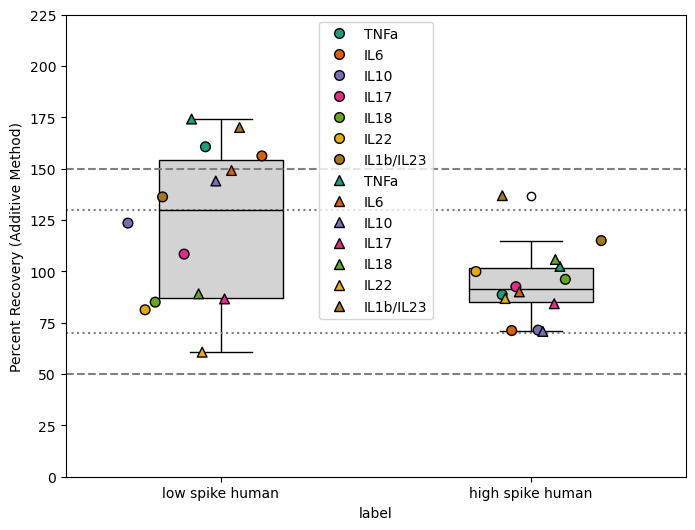

In [23]:
#merge the two dataframes   
rep1_df = allvals_df[allvals_df['rep'] == 'replicate 1']
rep2_df = allvals_df[allvals_df['rep'] == 'replicate 2']

plt.figure(figsize=(8, 6))
# have two different markers for the swarm plot based 'rep' column

sns.stripplot(x='label', y='percent_recovery_sub', data=rep1_df, hue='cytokine', palette='Dark2', size=7, order =['low spike human', 'high spike human'], marker='o',edgecolor='black', linewidth=1, jitter=0.3)
sns.stripplot(x='label', y='percent_recovery_sub', data=rep2_df, hue='cytokine', palette='Dark2', size=7, order =['low spike human', 'high spike human'], marker='^', edgecolor='black', linewidth=1)

sns.boxplot(x='label', y='percent_recovery_sub', data=allvals_df,   order =['low spike human', 'high spike human'], color="lightgray", linecolor='black', width=.4)
plt.axhline(y=130, color='gray', linestyle=':')
plt.axhline(y=70, color='gray', linestyle=':')
plt.axhline(y=150, color='gray', linestyle='--')
plt.axhline(y=50, color='gray', linestyle='--')
plt.ylim(0, 225)
plt.ylabel('Percent Recovery (Additive Method)')

In [24]:
columns=['mammal', 'cytokine', 'rep', 'base', 'calculated_conc','corrected', 'true', 'percent_recovery_sub','label','lod']
human=allvals_df[columns]
mouse=mouse_allvals_df[columns]
# concatenate human and mouse dataframes
combined_df = pd.concat([human, mouse], ignore_index=True)

# add a new column for plot is true if base< true else false
combined_df['is_spiked_above_base'] = combined_df.apply(lambda row: row['true'] > row['base'], axis=1)

In [25]:
# save combined_df to csv

combined_df


,mammal,cytokine,rep,base,calculated_conc,corrected,true,percent_recovery_sub,label,lod,is_spiked_above_base
0,human,TNFa,replicate 1,0.132188,35.594752,35.462565,40.0,88.656412,high spike human,0.132188,True
1,human,TNFa,replicate 1,0.132188,2.703154,2.570966,1.6,160.685377,low spike human,0.132188,True
2,human,TNFa,replicate 2,0.132188,41.095029,40.962842,40.0,102.407104,high spike human,0.132188,True
3,human,TNFa,replicate 2,0.132188,2.919340,2.787152,1.6,174.197005,low spike human,0.132188,True
4,human,IL6,replicate 1,0.023673,28.496465,28.472792,40.0,71.181980,high spike human,0.023673,True
5,human,IL6,replicate 1,0.023673,2.523471,2.499798,1.6,156.237397,low spike human,0.023673,True
6,human,IL6,replicate 2,0.073419,36.083566,36.010147,40.0,90.025368,high spike human,0.023673,True
7,human,IL6,replicate 2,0.073419,2.459672,2.386253,1.6,149.140836,low spike human,0.023673,True
8,human,IL10,replicate 1,0.222886,28.779524,28.556638,40.0,71.391594,high spike human,0.012800,True
9,human,IL10,replicate 1,0.222886,2.199144,1.976258,1.6,123.516142,low spike human,0.012800,True


In [26]:
print("Unique cytokines in combined_df:")
print(sorted(combined_df['cytokine'].unique()))

Unique cytokines in combined_df:
['IL10', 'IL17', 'IL18', 'IL1b/IL23', 'IL22', 'IL6', 'TNFa']


/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_61145/3304367404.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=90)
/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_61145/3304367404.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_61145/3304367404.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=90)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/seaborn/categorical.py:3399: Use

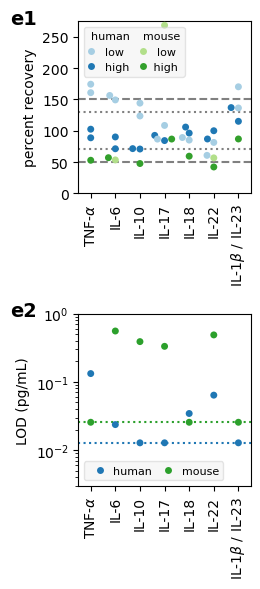

In [36]:

fig, axes = plt.subplots(2,1, figsize=(5, 6), layout='constrained')


order=['low spike human', 'high spike human', 'low spike mouse', 'high spike mouse']

# only plot percent_recovery_sub if is_spiked_above_base is True
combined_df_spike_above_base = combined_df[combined_df['is_spiked_above_base'] == True]

ax=axes[0]
sns.swarmplot(data=combined_df_spike_above_base, x='cytokine', y='percent_recovery_sub', hue="label", ax=ax, palette="Paired", hue_order=order)
# fix the cytokine legends so that they have a dash and add the actual greek letters
cytokine_labels = {
    'IL10': 'IL-10',
    'IL17': 'IL-17', 
    'IL18': 'IL-18',
    'IL1b/IL23': r'IL-1$\beta$ / IL-23',
    'IL22': 'IL-22',
    'IL6': 'IL-6',
    'TNFa': r'TNF-$\alpha$'
}

# Get current tick labels and replace them
current_labels = [item.get_text() for item in ax.get_xticklabels()]
new_labels = [cytokine_labels.get(label, label) for label in current_labels]
ax.set_xticklabels(new_labels, rotation=90)
ax.axhline(y=130, color='gray', linestyle=':')
ax.axhline(y=70, color='gray', linestyle=':')
ax.axhline(y=150, color='gray', linestyle='--')
ax.axhline(y=50, color='gray', linestyle='--')
ax.set_ylim(0, 275)
ax.set_ylabel('percent recovery')
ax.set_xlabel('')

ax.set_box_aspect(1)

plt.tight_layout()

# Create hierarchical legend with sub-headings

# Get current legend handles and labels
handles, labels = ax.get_legend_handles_labels()

# Remove the default legend
ax.get_legend().remove()

# Create custom legend elements
legend_elements = []

# Add main title

# Add Human subheading
# make legend two columns 
# remove outline for legend circles
ms=5
legend_elements.append(Line2D([0], [0], marker='', color='w', markerfacecolor='w', 
                             markersize=0, label='human', linestyle='None' 
                         ))

# Add human spike levels with proper colors from the palette
palette_colors = sns.color_palette("Paired", n_colors=4)
legend_elements.append(Line2D([0], [0], marker='o', color='none', markerfacecolor=palette_colors[0], 
                             markersize=ms, label='    low', linestyle='None', mec='none'))
legend_elements.append(Line2D([0], [0], marker='o', color='none', markerfacecolor=palette_colors[1], 
                             markersize=ms, label='    high', linestyle='None', mec='none'))

# Add Mouse subheading  
legend_elements.append(Line2D([0], [0], marker='', color='none', markerfacecolor='none', 
                             markersize=0, label='mouse', linestyle='None', 
                             ))

# Add mouse spike levels
legend_elements.append(Line2D([0], [0], marker='o', color='none', linewidth=0, markerfacecolor=palette_colors[2], 
                             markersize=ms, label='    low', linestyle='None', mec='none'))
legend_elements.append(Line2D([0], [0], marker='o', color='none', markerfacecolor=palette_colors[3], 
                             markersize=ms, label='   high', linestyle='None', mec='none'))

# Create the legend with tighter spacing to move text further left
ax.legend(handles=legend_elements, 
          #bbox_to_anchor=(1.02, 1), 
          loc='upper left',
          frameon=True, handlelength=0.5, handletextpad=-.3, 
          columnspacing=1, ncol=2,
          facecolor='#F0F0F0',
          fontsize=8,
          framealpha=0.5)



for i, ax in enumerate(axes):
    ax.annotate(f'e{i+1}', xy=(0, 1), xycoords='axes fraction',
                xytext=(-30, -5), textcoords='offset points',
                ha='right', va='bottom', fontsize=14, fontweight='bold')
    

ax=axes[1]
ax.set_box_aspect(1)

# add limit of dectection information to the second figure using 'lod' column from combined_df
lod_info = combined_df[['cytokine', 'mammal', 'lod']].drop_duplicates()
order=['human', 'mouse' ]
custom_palette = {'human': 'tab:blue', 'mouse': 'tab:green'}
sns.swarmplot(data=lod_info, x='cytokine', y='lod', hue="mammal", ax=ax, hue_order=order, palette=custom_palette)
# fix the cytokine legends so that they have a dash and add the actual greek letters
cytokine_labels = {
    'IL10': 'IL-10',
    'IL17': 'IL-17', 
    'IL18': 'IL-18',
    'IL1b/IL23': r'IL-1$\beta$ / IL-23',
    'IL22': 'IL-22',
    'IL6': 'IL-6',
    'TNFa': r'TNF-$\alpha$'
}

ax.axhline(y=0.0128, color='tab:blue', linestyle=':')
ax.axhline(y=0.0256, color='tab:green', linestyle=':')


ax.set_xticklabels(new_labels, rotation=90)
ax.set_yscale('log')
ax.set_ylabel('LOD (pg/mL)')
ax.set_xlabel('')
ax.set_ylim(3e-3,1e0)

# set background alpha for legend to 0.5
ax.legend(#handles=legend_elements, 
          #bbox_to_anchor=(1.02, 1), 
          loc='lower left',
          frameon=True, 
          #handlelength=0.5, 
          handletextpad=0.2, 
          columnspacing=0.5, ncol=2,
          facecolor='#F0F0F0',
          fontsize=8,
          framealpha=0.5)
plt.tight_layout()
fig.savefig(figures+'spike_lod.pdf')


In [28]:
lod_info = combined_df[['cytokine', 'mammal', 'lod']].drop_duplicates()
# save lod_info to csv
lod_info.to_csv('tables/spike_recovery_lod_info.csv', index=False)
lod_info



OSError: Cannot save file into a non-existent directory: 'tables'

In [ ]:
extended_data_path = '../document/tables/extended_data_tables.xlsx'

with pd.ExcelWriter(extended_data_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    combined_df.to_excel(writer, sheet_name='Spike_Recovery', index=False)
    lod_info.to_excel(writer, sheet_name='LOD_Spike_Recovery', index=False)